<a href="https://colab.research.google.com/github/KimJongBin01/session-based-IDS-Contrastive-Learning-/blob/main/session_based_IDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<Eclog(정상 트래픽)>**

실제 폴란드 온라인 쇼핑몰의 nginx 서버 엑세스 로그
하루치 데이터 -> 35만건의 HTTP 요청
IP,UA, timestamp, method, status, bytes, referrer 필드를 갖음

**<CSIC 2010(공격 트래픽)>**

스페인 국립연구회가 자동 생성한 e-commerce 웹/앱 HTTP 트래픽
정상요청 36000건, 공격 25000건
공격 유형은 SQLi, XSS, Buffer overflow, CRLFi 등 다양함

**<대조 학습을 위한 데이터 전처리>**

**1. EClog** (정상 데이터)

봇 필터링(자동으로 요청한 건)

정상 데이터 2024개 (IP) 선별 -> 세션분리 IpId 기준 30분 타임아웃, 선별 후 세션화 메서드 적용


**2. Positive pair**

정상 요청에 Dropout + Jitter 증강


**3. Negative pair**

정상 요청 + CISC 공격 요청 (공격이 섞인 세션)


In [1]:
# 셀 1 — 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls -lh /content/drive/MyDrive/csic2010/

total 225M
-rw------- 1 root root 16M May 11 07:10 anomalousTrafficTest.txt
-rw------- 1 root root 20M May 12 10:07 attack_requests.pkl
-rw------- 1 root root 94M May 11 06:11 eclog_1day.csv
-rw------- 1 root root 20M May 11 07:10 normalTrafficTest.txt
-rw------- 1 root root 20M May 11 07:10 normalTrafficTraining.txt
-rw------- 1 root root 58M May 11 07:24 web_logs.pkl


In [3]:
import os
from google.colab import files
import pandas as pd
import random
import matplotlib.pyplot as plt
import pickle

In [4]:
DRIVE_PATH = "/content/drive/MyDrive/csic2010"
os.makedirs(DRIVE_PATH, exist_ok=True)

# 드라이브에 없을 때만 다운로드
files = {
    "normalTrafficTraining.txt": f"{DRIVE_PATH}/normalTrafficTraining.txt",
    "anomalousTrafficTest.txt":  f"{DRIVE_PATH}/anomalousTrafficTest.txt",
    "normalTrafficTest.txt":     f"{DRIVE_PATH}/normalTrafficTest.txt",
}

BASE_URL = "https://raw.githubusercontent.com/msudol/Web-Application-Attack-Datasets/master/OriginalDataSets/csic_2010"

for filename, filepath in files.items():
    if not os.path.exists(filepath):
        print(f"다운로드 중: {filename}")
        os.system(f'wget -q "{BASE_URL}/{filename}" -O "{filepath}"')
    else:
        print(f"이미 있음: {filename}")

print("완료!")

이미 있음: normalTrafficTraining.txt
이미 있음: anomalousTrafficTest.txt
이미 있음: normalTrafficTest.txt
완료!


In [5]:
# 드라이브에서 로드

normal_train_path = f"{DRIVE_PATH}/normalTrafficTraining.txt"
anomalous_path    = f"{DRIVE_PATH}/anomalousTrafficTest.txt"
normal_test_path  = f"{DRIVE_PATH}/normalTrafficTest.txt"


In [6]:
# 처음 50줄 확인
with open(DRIVE_PATH+"/normalTrafficTraining.txt", "r", encoding="latin-1") as f:
    for i, line in enumerate(f):
        print(line, end="")
        if i > 50:
            break

GET http://localhost:8080/tienda1/index.jsp HTTP/1.1
User-Agent: Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)
Pragma: no-cache
Cache-control: no-cache
Accept: text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5
Accept-Encoding: x-gzip, x-deflate, gzip, deflate
Accept-Charset: utf-8, utf-8;q=0.5, *;q=0.5
Accept-Language: en
Host: localhost:8080
Cookie: JSESSIONID=1F767F17239C9B670A39E9B10C3825F4
Connection: close


GET http://localhost:8080/tienda1/publico/anadir.jsp?id=3&nombre=Vino+Rioja&precio=100&cantidad=55&B1=A%F1adir+al+carrito HTTP/1.1
User-Agent: Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)
Pragma: no-cache
Cache-control: no-cache
Accept: text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5
Accept-Encoding: x-gzip, x-deflate, gzip, deflate
Accept-Charset: utf-8, utf-8;q=0.5, *;q=0.5
Accept-Language: en
Host: localhost:8080
Cookie: 

**EClog**

정상데이터 확인

In [7]:
# Eclog 데이터셋 로드
df = pd.read_csv("/content/drive/MyDrive/csic2010/eclog_1day.csv")

# web_logs 로드
with open("/content/drive/MyDrive/csic2010/web_logs.pkl", "rb") as f:
    web_logs = pickle.load(f)

print(f"EClog 로드 완료: {len(df):,}건")
print(f"web_logs 로드 완료: {len(web_logs):,}개")

EClog 로드 완료: 350,683건
web_logs 로드 완료: 2,248개


In [8]:
# Eclog 데이터 읽어들이기
df = pd.read_csv("/content/drive/MyDrive/csic2010/eclog_1day.csv", nrows=5)
print(f"컬럼: {df.columns.tolist()}")
print(f"\n=== 첫 5행 ===")
print(df.head())

컬럼: ['IpId', 'UserId', 'TimeStamp', 'HttpMethod', 'Uri', 'HttpVersion', 'ResponseCode', 'Bytes', 'Referrer', 'UserAgent']

=== 첫 5행 ===
  IpId UserId           TimeStamp HttpMethod                          Uri  \
0  1PL      -  637116156000000000       POST  /inne/informacja_online.php   
1  1PL      -  637116156010000000       POST  /inne/informacja_online.php   
2  2NL      -  637116156010000000        GET    /wyszukiwanie-query1.html   
3  3PL      -  637116156050000000       POST  /inne/informacja_online.php   
4  4PL      -  637116156050000000       POST  /inne/informacja_online.php   

  HttpVersion  ResponseCode  Bytes  \
0    HTTP/1.1           200      0   
1    HTTP/1.1           200      0   
2    HTTP/1.1           200   9018   
3    HTTP/1.1           200      0   
4    HTTP/1.1           200      0   

                                            Referrer  \
0   https://shop.our-internet-company.pl/p-5315.html   
1  https://shop.our-internet-company.pl/p-10152.html   
2   

In [9]:
# 전체 로드 + 기본 통계
df = pd.read_csv("/content/drive/MyDrive/csic2010/eclog_1day.csv")

print(f"총 요청 수: {len(df):,}")
print(f"\n=== ResponseCode 분포 ===")
print(df["ResponseCode"].value_counts().head(10))

print(f"\n=== HttpMethod 분포 ===")
print(df["HttpMethod"].value_counts())

print(f"\n=== 고유 IpId 수 ===")
print(f"{df['IpId'].nunique():,}명")

print(f"\n=== 고유 UserId 수 ===")
print(f"{df['UserId'].nunique():,}명")

총 요청 수: 350,683

=== ResponseCode 분포 ===
ResponseCode
200    338043
304      6847
301      3387
302      1471
499       388
404       307
206       150
403        72
400        11
408         7
Name: count, dtype: int64

=== HttpMethod 분포 ===
HttpMethod
GET     288556
POST     62075
HEAD        43
-            9
Name: count, dtype: int64

=== 고유 IpId 수 ===
4,297명

=== 고유 UserId 수 ===
1명


In [10]:
# 세션 분리 가능한지 확인
# IpId 기반으로 요청 묶어보기
sample_ip = df["IpId"].iloc[0]

# ip 하나 잡아서 요청 시간 순으로
ip_df = df[df["IpId"] == sample_ip].sort_values("TimeStamp")

print(f"IpId: {sample_ip}")
print(f"요청 수: {len(ip_df)}")
print(f"\n=== 흐름 ===")
print(ip_df[["IpId", "TimeStamp", "HttpMethod", "Uri", "ResponseCode"]].to_string())

IpId: 1PL
요청 수: 236

=== 흐름 ===
      IpId           TimeStamp HttpMethod                          Uri  ResponseCode
0      1PL  637116156000000000       POST  /inne/informacja_online.php           200
1      1PL  637116156010000000       POST  /inne/informacja_online.php           200
13     1PL  637116156100000000       POST  /inne/informacja_online.php           200
15     1PL  637116156130000000       POST  /inne/informacja_online.php           200
28     1PL  637116156250000000       POST  /inne/informacja_online.php           200
37     1PL  637116156310000000       POST  /inne/informacja_online.php           200
102    1PL  637116156420000000       POST  /inne/informacja_online.php           200
120    1PL  637116156600000000       POST  /inne/informacja_online.php           200
123    1PL  637116156630000000       POST  /inne/informacja_online.php           200
127    1PL  637116156650000000       POST  /inne/informacja_online.php           200
128    1PL  637116156660000000   

In [11]:
# URI 다양성 기준으로 정상 IP 필터링
# IP 기준으로 그룹핑 + 기본 통계
ip_stats = df.groupby("IpId").agg(
    total_requests=("Uri", "count"), # 총 요청 개수
    unique_uris=("Uri", "nunique"),  # 중복을 제외한 Uri 개수(방문항 페이지 종류)
    unique_methods=("HttpMethod", "nunique") # 중복 제외한 CRUD 메서드 종류
).reset_index() # 일반 컬럼으로 쓰기 위함

# URI 다양성 비율 계산 (실제 사용 URI 종류) / (전체 요청 개수)
ip_stats["uri_diversity"] = ip_stats["unique_uris"] / ip_stats["total_requests"]

print("=== IP별 통계 샘플 ===")
print(ip_stats.sort_values("total_requests", ascending=False).head(20))

=== IP별 통계 샘플 ===
        IpId  total_requests  unique_uris  unique_methods  uri_diversity
4241   950PL            6613         2394               2       0.362014
3850   599PL            6147         2716               2       0.441842
2843  3560PL            4870         2227               2       0.457290
3812   564PL            3601         1514               2       0.420439
1450  2306PL            3480         2509               2       0.720977
3349  4015PL            3292         1173               2       0.356318
310   1280PL            2667          368               2       0.137983
332     12US            2446         1835               2       0.750204
1875   268PL            2371         1940               2       0.818220
317   1287PL            2327         1883               2       0.809196
2953   365PL            2311         1814               2       0.784942
1456  2311PL            2297           53               2       0.023074
3098  3790PL            2222     

In [12]:
# 정상 사용자 필터링
# uri_diversity > 0.3, 요청 수 3~500개

# IpId만 뽑아냄
normal_ips = ip_stats[
    (ip_stats["uri_diversity"] > 0.3) &
    (ip_stats["total_requests"] >= 3) &
    (ip_stats["total_requests"] <= 500)
]["IpId"]

print(f"전체 IP 수: {len(ip_stats):,}")
print(f"정상 IP 수: {len(normal_ips):,}")

# 정상 IP의 요청만 필터링
normal_df = df[df["IpId"].isin(normal_ips)].copy()
print(f"\n정상 요청 수: {len(normal_df):,}")

# 샘플 IP 흐름 확인
sample_ip = normal_ips.iloc[0] # 첫번째 ip 꺼내기 (샘플ip)
sample_df = normal_df[normal_df["IpId"] == sample_ip].sort_values("TimeStamp")
print(f"\n=== 정상 사용자 샘플 ({sample_ip}) ===")
print(sample_df[["TimeStamp", "HttpMethod", "Uri", "ResponseCode"]].head(15).to_string())

전체 IP 수: 4,297
정상 IP 수: 2,024

정상 요청 수: 204,309

=== 정상 사용자 샘플 (1002PL) ===
                TimeStamp HttpMethod                                                                                  Uri  ResponseCode
73728  637116520720000000        GET           /p-3388.html?gclid=EAIaIQobChMIuvLUrJ-t5gIVRpZ3Ch1k0wFiEAEYASAGEgLtE_D_BwE           200
73729  637116520720000000        GET  /szablony/shop_11.rwd/css/style.php?ncss=style,boxy,moduly,produkt,zebra_datepicker           200
73730  637116520720000000        GET                                                              /javascript/skrypty.php           200
73732  637116520720000000        GET                                                                /javascript/jquery.js           304
73733  637116520720000000        GET                                                              /javascript/produkt.php           200
73734  637116520720000000        GET                                   /szablony/shop_3.rwd/obrazki/szablon/

In [13]:
# timestamp 단위 사람이 보기 편하게 바꾸기
# .NET DateTime 형식: 637116520720000000 / 10000000 = Unix초 변환 필요
# timestamp 변환 (.NET ticks → datetime)
# .NET epoch: 0001-01-01 00:00:00
# Unix epoch: 1970-01-01 00:00:00
# 차이: 621355968000000000 ticks

normal_df = normal_df.copy()
normal_df["dt_seconds"] = (normal_df["TimeStamp"] - 621355968000000000) / 10000000
normal_df["datetime"] = pd.to_datetime(normal_df["dt_seconds"], unit='s')

print("=== timestamp 변환 확인 ===")
print(normal_df[["TimeStamp", "datetime"]].head(5))

=== timestamp 변환 확인 ===
             TimeStamp            datetime
2   637116156010000000 2019-12-10 23:00:01
8   637116156080000000 2019-12-10 23:00:08
12  637116156100000000 2019-12-10 23:00:10
19  637116156150000000 2019-12-10 23:00:15
26  637116156220000000 2019-12-10 23:00:22


In [14]:
# 세션 분리 (IpId + 30분 타임아웃)
normal_df = normal_df.sort_values(["IpId", "dt_seconds"])

web_logs = []
current_session = []
prev_ip = None
prev_time = None
TIMEOUT = 1800  # 30분

for _, row in normal_df.iterrows():
    ip = row["IpId"]
    t  = row["dt_seconds"]

    if prev_ip is None:
        current_session = [row]

    elif ip != prev_ip or (t - prev_time) > TIMEOUT:
        if len(current_session) >= 3:
            web_logs.append(current_session)
        current_session = [row]

    else:
        current_session.append(row)

    prev_ip   = ip
    prev_time = t

if len(current_session) >= 3:
    web_logs.append(current_session)

print(f"총 세션 수: {len(web_logs):,}")
print(f"세션당 평균 요청 수: {sum(len(s) for s in web_logs) / len(web_logs):.1f}")
print(f"최소 요청 수: {min(len(s) for s in web_logs)}")
print(f"최대 요청 수: {max(len(s) for s in web_logs)}")

총 세션 수: 2,248
세션당 평균 요청 수: 90.7
최소 요청 수: 3
최대 요청 수: 499


In [15]:
print(web_logs[0])

[IpId                                                       1002PL
UserId                                                          -
TimeStamp                                      637116520720000000
HttpMethod                                                    GET
Uri             /p-3388.html?gclid=EAIaIQobChMIuvLUrJ-t5gIVRpZ...
HttpVersion                                              HTTP/1.1
ResponseCode                                                  200
Bytes                                                       13596
Referrer        https://tpc.googlesyndication.com/safeframe/1-...
UserAgent       Mozilla/5.0 (Windows NT 5.1; rv:52.0) Gecko/20...
dt_seconds                                           1576055272.0
datetime                                      2019-12-11 09:07:52
Name: 73728, dtype: object, IpId                                                       1002PL
UserId                                                          -
TimeStamp                                      

In [16]:
# 세션 하나 샘플 확인
sample = random.choice(web_logs)
print(f"세션 요청 수: {len(sample)}")
print(f"\n=== 세션 흐름 (앞 15개) ===")
for req in sample[:15]:
    print(f"  {req['datetime']}  {req['HttpMethod']}  {req['Uri'][:60]}  {req['ResponseCode']}")

세션 요청 수: 135

=== 세션 흐름 (앞 15개) ===
  2019-12-11 21:16:31  GET  /c-272.html  200
  2019-12-11 21:16:31  GET  /szablony/shop_11.rwd/css/style.php?ncss=style,boxy,moduly,p  200
  2019-12-11 21:16:31  GET  /javascript/jquery.js  200
  2019-12-11 21:16:31  GET  /javascript/skrypty.php  200
  2019-12-11 21:16:32  GET  /szablony/shop_11.rwd/obrazki/szablon/tlo_menu_naglowka_spod  200
  2019-12-11 21:16:32  GET  /szablony/shop_11.rwd/obrazki/szablon/tlo_menu_naglowka.png  200
  2019-12-11 21:16:32  GET  /szablony/shop_11.rwd/obrazki/szablon/separator_menu.png  200
  2019-12-11 21:16:32  GET  /szablony/shop_11.rwd/obrazki/szablon/tlo_naglowek_boxu.png  200
  2019-12-11 21:16:32  GET  /szablony/shop_11.rwd/obrazki/szablon/box_cien.png  200
  2019-12-11 21:16:32  GET  /szablony/shop_11.rwd/obrazki/nawigacja/zobacz_wszystkie_box  200
  2019-12-11 21:16:32  GET  /szablony/shop_3.rwd/obrazki/szablon/rwd_szukaj.png  200
  2019-12-11 21:16:32  GET  /szablony/shop_3.rwd/obrazki/szablon/rwd_konto.png  

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50937 (\N{HANGUL SYLLABLE WEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

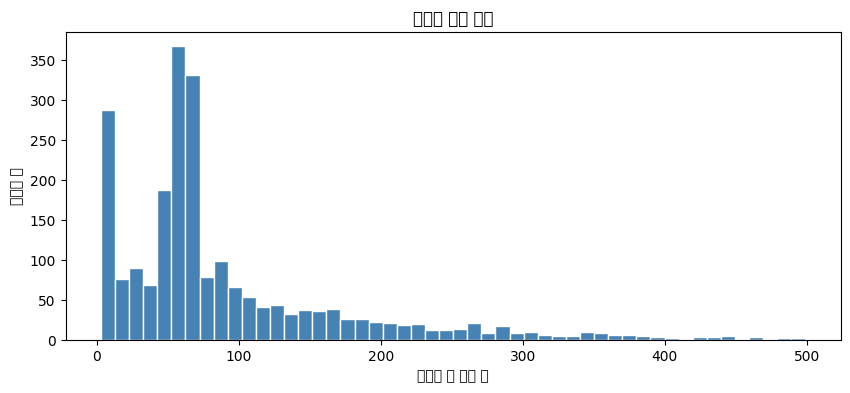


10개 이하 웹로그: 266개
10~50개 웹로그:   391개
50~100개 웹로그:  983개
100개 이상 웹로그: 608개


In [17]:
# 세션 길이 분포 확인
lengths = [len(s) for s in web_logs]
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.xlabel("웹로그 내 요청 수")
plt.ylabel("웹로그 수")
plt.title("웹로그 길이 분포")
plt.show()

print(f"\n10개 이하 웹로그: {sum(1 for l in lengths if l <= 10):,}개")
print(f"10~50개 웹로그:   {sum(1 for l in lengths if 10 < l <= 50):,}개")
print(f"50~100개 웹로그:  {sum(1 for l in lengths if 50 < l <= 100):,}개")
print(f"100개 이상 웹로그: {sum(1 for l in lengths if l > 100):,}개")

**CSIC 데이터셋으로부터 공격 생성**

인공지능에게는 공격 유형 분석을 맡김

In [18]:
# POST 요청 원본 확인
with open("/content/drive/MyDrive/csic2010/anomalousTrafficTest.txt", "r", encoding="latin-1") as f:
    content = f.read()

# POST 요청 찾아서 원본 출력
lines = content.split('\n')
for i, line in enumerate(lines):
    if line.startswith("POST"):
        print(f"=== POST 요청 원본 (라인 {i}) ===")
        for j in range(i, min(i+15, len(lines))):
            print(f"{j}: {repr(lines[j])}")
        print()
        break

=== POST 요청 원본 (라인 13) ===
13: 'POST http://localhost:8080/tienda1/publico/anadir.jsp HTTP/1.1'
14: 'User-Agent: Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)'
15: 'Pragma: no-cache'
16: 'Cache-control: no-cache'
17: 'Accept: text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5'
18: 'Accept-Encoding: x-gzip, x-deflate, gzip, deflate'
19: 'Accept-Charset: utf-8, utf-8;q=0.5, *;q=0.5'
20: 'Accept-Language: en'
21: 'Host: localhost:8080'
22: 'Cookie: JSESSIONID=AE29AEEBDE479D5E1A18B4108C8E3CE0'
23: 'Content-Type: application/x-www-form-urlencoded'
24: 'Connection: close'
25: 'Content-Length: 146'
26: ''
27: 'id=2&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad=%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25&B1=A%F1adir+al+carrito'



In [19]:
def parse_single_request(lines):
    if not lines:
        return None
    req = {
        "method": None, "url": None, "path": None,
        "params": {}, "headers": {}, "body": None,
        "user_agent": None, "cookie": None,
        "has_cookie": False,
    }
    try:
        first_line = lines[0].strip()
        HTTP_METHODS = ["GET", "POST", "PUT", "DELETE", "HEAD", "OPTIONS"]
        if not any(first_line.startswith(m) for m in HTTP_METHODS):
            return None

        parts = first_line.split(" ")
        req["method"] = parts[0]
        req["url"]    = parts[1] if len(parts) > 1 else ""

        if "?" in req["url"]:
            req["path"] = req["url"].split("?")[0]
            for param in req["url"].split("?")[1].split("&"):
                if "=" in param:
                    k, v = param.split("=", 1)
                    req["params"][k] = v
        else:
            req["path"] = req["url"]

        # 헤더 파싱
        body_start = None
        for i, line in enumerate(lines[1:], 1):
            if line.strip() == "":
                body_start = i + 1  # 빈 줄 다음이 body
                break
            if ": " in line:
                k, v = line.split(": ", 1)
                k = k.strip().lower()
                req["headers"][k] = v.strip()
                if k == "user-agent":   req["user_agent"] = v.strip()
                elif k == "cookie":     req["cookie"] = v.strip(); req["has_cookie"] = True

        # POST body 파싱 ← 수정된 부분
        if req["method"] == "POST" and body_start is not None:
            # body_start 이후 비어있지 않은 첫 줄
            for i in range(body_start, len(lines)):
                body = lines[i].strip()
                if body:
                    req["body"] = body
                    for param in body.split("&"):
                        if "=" in param:
                            k, v = param.split("=", 1)
                            req["params"][k] = v
                    break

    except:
        return None
    return req

print("파싱 함수 수정 완료!")

파싱 함수 수정 완료!


In [20]:
def parse_requests(filepath):
    requests, current = [], []
    with open(filepath, "r", encoding="latin-1") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].rstrip('\n')

        # HTTP 메서드로 시작하는 줄 = 새 요청 시작
        HTTP_METHODS = ["GET ", "POST ", "PUT ", "DELETE ", "HEAD "]
        if any(line.startswith(m) for m in HTTP_METHODS):
            if current:
                req = parse_single_request(current)
                if req: requests.append(req)
            current = [line]
        elif current:
            current.append(line)

        i += 1

    # 마지막 요청 처리
    if current:
        req = parse_single_request(current)
        if req: requests.append(req)

    return requests

print("parse_requests 수정 완료!")

parse_requests 수정 완료!


In [21]:
# 파싱 실행
attack_requests = parse_requests(
    "/content/drive/MyDrive/csic2010/anomalousTrafficTest.txt"
)
print(f"공격 요청 수: {len(attack_requests):,}")

공격 요청 수: 25,065


In [22]:
# path 분포 확인
from collections import Counter

attack_paths = [r["path"] for r in attack_requests if r["path"]]
print("=== 공격 Path 분포 (상위 20개) ===")
for path, cnt in Counter(attack_paths).most_common(20):
    print(f"  {cnt:4d}  {path}")

=== 공격 Path 분포 (상위 20개) ===
  2821  http://localhost:8080/tienda1/publico/anadir.jsp
  2783  http://localhost:8080/tienda1/publico/autenticar.jsp
  2781  http://localhost:8080/tienda1/publico/registro.jsp
  2774  http://localhost:8080/tienda1/miembros/editar.jsp
  2722  http://localhost:8080/tienda1/publico/pagar.jsp
  1957  http://localhost:8080/tienda1/publico/caracteristicas.jsp
  1884  http://localhost:8080/tienda1/publico/vaciar.jsp
  1835  http://localhost:8080/tienda1/publico/entrar.jsp
    51  http://localhost:8080/tienda1/asf-logo-wide.gif
    51  http://localhost:8080/
    49  http://localhost:8080/tienda1/asf-logo-wide.gif/
    47  http://localhost:8080/tienda1/6909030637832563290.jsp
    46  http://localhost:8080/tienda1/asf-logo-wide
    39  http://localhost:8080/asf-logo-wide
    38  http://localhost:8080/tienda1/4861362529278789730
    38  http://localhost:8080/asf-logo-wide.gif/
    37  http://localhost:8080/asf-logo-wide.gif
    36  http://localhost:8080/48613625292787

In [23]:
# 공격 요청 샘플 확인
print("=== 공격 요청 샘플 10개 ===")
for req in attack_requests[:10]:
    print(f"\nMethod: {req['method']}")
    print(f"URL:    {req['url'][:100]}")
    print(f"Params: {req['params']}")
    print(f"Body:   {req['body']}")

=== 공격 요청 샘플 10개 ===

Method: GET
URL:    http://localhost:8080/tienda1/publico/anadir.jsp?id=2&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad=%2
Params: {'id': '2', 'nombre': 'Jam%F3n+Ib%E9rico', 'precio': '85', 'cantidad': '%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25', 'B1': 'A%F1adir+al+carrito'}
Body:   None

Method: POST
URL:    http://localhost:8080/tienda1/publico/anadir.jsp
Params: {'id': '2', 'nombre': 'Jam%F3n+Ib%E9rico', 'precio': '85', 'cantidad': '%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25', 'B1': 'A%F1adir+al+carrito'}
Body:   id=2&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad=%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25&B1=A%F1adir+al+carrito

Method: GET
URL:    http://localhost:8080/tienda1/publico/anadir.jsp?id=2%2F&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad
Params: {'id': '2%2F', 'nombre': 'Jam%F3n+Ib%E9rico', 'precio': '85', 'cantidad': '49', 'B1': 'A%F1adir+al+carrito'}
Body:  

In [24]:
# method 분포
attack_methods = [r["method"] for r in attack_requests if r["method"]]
print("=== 공격 Method 분포 ===")
for method, cnt in Counter(attack_methods).most_common():
    print(f"  {cnt:4d}  {method}")

=== 공격 Method 분포 ===
  15088  GET
  9580  POST
   397  PUT


In [25]:
# 다시 파싱
attack_requests = parse_requests("/content/drive/MyDrive/csic2010/anomalousTrafficTest.txt")
print(f"공격 요청 수: {len(attack_requests):,}")

# POST body 확인
post_reqs = [r for r in attack_requests if r["method"] == "POST"]
print(f"POST 요청 수: {len(post_reqs):,}")
for req in post_reqs[:3]:
    print(f"\nMethod: {req['method']}")
    print(f"Path:   {req['path']}")
    print(f"Body:   {req['body']}")
    print(f"Params: {req['params']}")

공격 요청 수: 25,065
POST 요청 수: 9,580

Method: POST
Path:   http://localhost:8080/tienda1/publico/anadir.jsp
Body:   id=2&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad=%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25&B1=A%F1adir+al+carrito
Params: {'id': '2', 'nombre': 'Jam%F3n+Ib%E9rico', 'precio': '85', 'cantidad': '%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25', 'B1': 'A%F1adir+al+carrito'}

Method: POST
Path:   http://localhost:8080/tienda1/publico/anadir.jsp
Body:   id=2%2F&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad=49&B1=A%F1adir+al+carrito
Params: {'id': '2%2F', 'nombre': 'Jam%F3n+Ib%E9rico', 'precio': '85', 'cantidad': '49', 'B1': 'A%F1adir+al+carrito'}

Method: POST
Path:   http://localhost:8080/tienda1/publico/autenticar.jsp
Body:   modo=entrar&login=bob%40%3CSCRipt%3Ealert%28Paros%29%3C%2FscrIPT%3E.parosproxy.org&pwd=84m3ri156&remember=on&B1=Entrar
Params: {'modo': 'entrar', 'login': 'bob%40%3CSCRipt%3Ealert%28Paros%29%3C%2Fsc

In [26]:
from urllib.parse import unquote_plus
import re
from collections import Counter

# ── 키워드 정의 ──────────────────────────────────────────

SQLI_KEYWORDS = [
    "SELECT", "DROP", "INSERT", "UPDATE", "DELETE",
    "UNION", "WHERE", "FROM", "HAVING", "GROUP BY",
    "OR 1=1", "AND 1=1", "OR '1'='1",
    "' OR", "\" OR",
    "--", "/*", "*/", "#",
    "SLEEP(", "BENCHMARK(", "WAITFOR", "EXEC(",
    "CAST(", "CONVERT(", "LIKE '%",
]

XSS_KEYWORDS = [
    "<SCRIPT", "</SCRIPT>", "<IFRAME", "<IMG",
    "<SVG", "<BODY", "<INPUT",
    "ONERROR=", "ONLOAD=", "ONCLICK=", "ONMOUSEOVER=",
    "ALERT(", "CONFIRM(", "PROMPT(",
    "JAVASCRIPT:", "VBSCRIPT:",
    "%3CSCRIPT", "%3C/SCRIPT",
    "253CSCRIPT", "&#60;SCRIPT",
]

TRAVERSAL_KEYWORDS = [
    "../", "..\\",
    "%2E%2E/", "%2E%2E\\",
    "..%2F", "..%5C",
    "%252E%252E",
    "ETC/PASSWD", "ETC/SHADOW",
    "WIN.INI", "BOOT.INI", "SYSTEM32",
    "IISSAMPLES",
    "6909030637832563290",
    "4861362529278789730",
]

CRLF_KEYWORDS = [
    "%0D%0A", "%0A%0D", "%0A", "%0D",
]

ABNORMAL_METHODS = [
    "PUT", "DELETE", "OPTIONS",
    "TRACE", "CONNECT", "PATCH",
]

BRUTEFORCE_PATHS = ["autenticar", "login", "signin"]

TAMPERING_SPECIAL = [
    "%2F", "%7C", "%2B", "%7E", "%2A", "*", "~",
    "%2500", "%253F", "%2C", "%3F", "%27", "%00",
    "%25", "%3C", "%3E", "%22", "%60",
    "%28", "%29", "%3B", "%40",
]

SCANNING_REGEX = [
    r"\.gif$", r"\.htm$", r"\.bak$",
    r"\.old$", r"\.inc$", r"\.asp$",
    r"jsp/$", r"gif/$", r"jpg/$", r"css/$",
    r"~$", r"\.java$",
    r"localhost:8080http",
    r"/publico/$", r"imagenes/$", r"global/$",
]

SCANNING_PATHS = [
    "iisstart", "travelnet", "asf-logo",
    "iissamples", "phpmyadmin", "manager/",
    "9090/examples", "wp-admin", ".env", ".git",
]


# ── 보조 함수 ──────────────────────────────────────────

def is_tampering(req):
    keys     = list(req["params"].keys())
    values   = list(req["params"].values())
    all_vals = " ".join(values)

    # 파라미터 키 이름 끝에 대문자 (idA, rememberA 등)
    if any(re.search(r'[a-zA-Z0-9][A-Z]$', k) for k in keys):
        return True

    # 값에 인코딩된 특수문자 포함
    if any(s.lower() in all_vals.lower() for s in TAMPERING_SPECIAL):
        return True

    # 값이 + 만 있거나 끝에 + 붙은 경우
    for v in values:
        v = v.strip()
        if v == "+" or v.endswith("+"):
            return True

    return False


def is_scanning(req):
    p = (req["path"] or "").lower()

    # 정규식 패턴 매칭
    if any(re.search(pat, p) for pat in SCANNING_REGEX):
        return True

    # 비정상 경로 포함
    if any(s in p for s in SCANNING_PATHS):
        return True

    # 파라미터 없고 tienda1도 없는 경로
    if not req["params"] and "tienda1" not in p:
        return True

    return False


# ── 메인 분류 함수 ──────────────────────────────────────

def classify_attack(req):
    url      = unquote_plus(req["url"] or "")
    body     = unquote_plus(req["body"] or "")
    params_raw = " ".join(req["params"].values())
    path     = req["path"] or ""

    try:
        params_decoded = unquote_plus(unquote_plus(params_raw))
    except:
        params_decoded = params_raw

    all_text = (url + " " + body + " " + params_decoded).upper()

    if any(k in all_text for k in SQLI_KEYWORDS):
        return "sqli"
    elif any(k in all_text for k in XSS_KEYWORDS):
        return "xss"
    elif any(k in all_text for k in TRAVERSAL_KEYWORDS):
        return "traversal"
    elif any(k in all_text for k in CRLF_KEYWORDS):
        return "crlf"
    elif req["method"] in ABNORMAL_METHODS:
        return "abnormal_method"
    elif is_tampering(req):
        return "tampering"
    elif any(p in path for p in BRUTEFORCE_PATHS):
        return "bruteforce"
    elif is_scanning(req):
        return "scanning"
    else:
        return "other"


In [27]:
for req in attack_requests:
    req["attack_type"] = classify_attack(req)

attack_types = [r["attack_type"] for r in attack_requests]
print("=== 최종 공격 유형 분포 ===")
for attack_type, cnt in Counter(attack_types).most_common():
    print(f"  {cnt:5d}  {attack_type}")

other_reqs = [r for r in attack_requests if r["attack_type"] == "other"]
print(f"\nother 남은 수: {len(other_reqs):,}")

=== 최종 공격 유형 분포 ===
  12264  tampering
   4721  sqli
   4270  scanning
   1374  xss
   1119  traversal
    826  crlf
    397  abnormal_method
     94  bruteforce

other 남은 수: 0


In [28]:
# other 중 패턴 분석
other_reqs = [r for r in attack_requests if r["attack_type"] == "other"]

# path 분포 확인
other_paths = [r["path"] for r in other_reqs if r["path"]]
print("=== other Path 분포 (상위 20개) ===")
for path, cnt in Counter(other_paths).most_common(20):
    print(f"  {cnt:4d}  {path}")

print("\n=== other params 샘플 ===")
for req in other_reqs[:10]:
    print(f"\nPath:   {req['path']}")
    print(f"Params: {req['params']}")
    print(f"Body:   {req['body']}")

=== other Path 분포 (상위 20개) ===

=== other params 샘플 ===


In [ ]:
import pickle
import os

os.makedirs("/content/drive/MyDrive/csic2010", exist_ok=True)

with open("/content/drive/MyDrive/csic2010/attack_requests.pkl", "wb") as f:
    pickle.dump(attack_requests, f)

print(f"저장 완료! 공격 요청 수: {len(attack_requests):,}")
!ls -lh /content/drive/MyDrive/csic2010/

저장 완료! 공격 요청 수: 25,065
total 225M
-rw------- 1 root root 16M May 11 07:10 anomalousTrafficTest.txt
-rw------- 1 root root 20M May 12 10:07 attack_requests.pkl
-rw------- 1 root root 94M May 11 06:11 eclog_1day.csv
-rw------- 1 root root 20M May 11 07:10 normalTrafficTest.txt
-rw------- 1 root root 20M May 11 07:10 normalTrafficTraining.txt
-rw------- 1 root root 58M May 11 07:24 web_logs.pkl


**대조 학습을 위한 준비**

In [29]:
# 지금 메모리에 있는 것들 확인
print(f"web_logs: {len(web_logs):,}개")
print(f"attack_requests: {len(attack_requests):,}개")

web_logs: 2,248개
attack_requests: 25,065개


In [33]:
# 웹로그 -> 세션으로 만든은 함수
import uuid
import hashlib

def sessionize(web_log):
    if not web_log:
        return None

    # client_key: JSESSIONID 우선, 없으면 IP + UA 해시
    def get_client_key(row):
        cookie = str(row.get("cookie", "") or "")
        if "JSESSIONID" in cookie:
            for part in cookie.split(";"):
                if "JSESSIONID" in part:
                    return part.strip()
        ip = str(row.get("IpId", ""))
        ua = str(row.get("UserAgent", ""))
        return hashlib.md5((ip + ua).encode()).hexdigest()[:16]

    session = {
        "session_id":  str(uuid.uuid4()),
        "client_key":  get_client_key(web_log[0]),
        "requests":    []
    }

    prev_timestamp = None

    for row in web_log:
        # timestamp 변환 (이미 dt_seconds로 변환된 값 사용)
        timestamp = float(row.get("dt_seconds", 0))

        # dt 계산
        dt = 0.0
        if prev_timestamp is not None:
            dt = timestamp - prev_timestamp
        prev_timestamp = timestamp

        # cookie 정보
        cookie = str(row.get("cookie", "") or "")
        has_cookie = len(cookie) > 0

        # cookie_changed (이전 요청과 비교)
        prev_cookie = session["requests"][-1]["cookie"] if session["requests"] else None
        cookie_changed = (prev_cookie is not None and prev_cookie != cookie)

        # URL 파싱
        uri = str(row.get("Uri", "") or "")
        if "?" in uri:
            path   = uri.split("?")[0]
            params = {}
            for param in uri.split("?")[1].split("&"):
                if "=" in param:
                    k, v = param.split("=", 1)
                    params[k] = v
        else:
            path   = uri
            params = {}

        req = {
            "ip":               str(row.get("IpId", "")),
            "timestamp":        timestamp,
            "method":           str(row.get("HttpMethod", "")),
            "path":             path,
            "params":           params,
            "status":           int(row.get("ResponseCode", 0)),
            "size":             int(row.get("Bytes", 0)),
            "user_agent":       str(row.get("UserAgent", "") or ""),
            "cookie":           cookie,
            "dt":               dt,
            "has_cookie":       has_cookie,
            "cookie_changed":   cookie_changed,
        }
        session["requests"].append(req)

    return session


# web_logs → sessions 변환
sessions = []
for web_log in web_logs:
    s = sessionize(web_log)
    if s:
        sessions.append(s)

print(f"sessions 수: {len(sessions):,}")

# 샘플 확인
s = sessions[0]
print(f"\nsession_id:  {s['session_id']}")
print(f"client_key:  {s['client_key']}")
print(f"요청 수:     {len(s['requests'])}")
print(f"\n=== 첫 3개 요청 ===")
for req in s["requests"][:3]:
    print(f"  {req['method']} {req['path']} {req['status']} dt={req['dt']:.1f}s has_cookie={req['has_cookie']}")

sessions 수: 2,248

session_id:  195a055f-3d1e-4c2f-9aaf-175139c17f3e
client_key:  ebe6db730c749e5d
요청 수:     60

=== 첫 3개 요청 ===
  GET /p-3388.html 200 dt=0.0s has_cookie=False
  GET /szablony/shop_11.rwd/css/style.php 200 dt=0.0s has_cookie=False
  GET /javascript/skrypty.php 200 dt=0.0s has_cookie=False


In [34]:
# Positive pair 만들기
def augment_session(session, dropout_p=0.15, jitter_p=0.3, jitter_rate=0.1):
    """
    dropout_p: 각 요청이 제거될 확률 (15%)
    jitter_p:  각 요청에 jitter가 적용될 확률 (30%)
    jitter_rate: jitter 범위 (±10%)
    """
    requests = session["requests"]

    # Step 1: Request Dropout
    if len(requests) > 3:
        result = [req for req in requests if random.random() > dropout_p]
        if len(result) < 3:
            result = requests[:3]
    else:
        result = requests[:]

    # Step 2: Temporal Jitter (일부 요청에만 적용)
    result = [copy.deepcopy(req) for req in result]
    for i in range(1, len(result)):
        if random.random() < jitter_p:  # 30% 확률로만 jitter 적용
            if result[i]["dt"] > 0:
                noise = result[i]["dt"] * random.uniform(-jitter_rate, jitter_rate)
                result[i]["dt"] = max(0.0, result[i]["dt"] + noise)

    augmented = copy.deepcopy(session)
    augmented["session_id"] = str(uuid.uuid4())
    augmented["requests"]   = result
    return augmented